# Chapter 7 — Strategy Taxonomy: Where Edges Come From

Chapter 6 gave us a working intraday data substrate and three pictures: the QQQ U-shape, the FOMC overlay, and time vs dollar bars. Ch8 will build a fully runnable mean-reversion strategy on QQQ end-to-end. Ch7 is the conceptual hinge between them: *before* you build a strategy, what is the question you should be asking, and what are the categories of answer?

This is the first chapter that doesn't run a backtest, doesn't fit a model, and barely uses any new statistics. The whole math budget is one autocorrelation curve. The point is to teach the reader to interrogate any candidate strategy with the question **"where does the edge come from, mechanically?"** — and to recognize when an edge is real versus when a chart pattern is a fitted artifact.

## Three things this chapter teaches you to ask

1. **Is this edge conditional, not universal?** Every viable strategy has a positive expectancy per trade *in some set of conditions* and not others. Knowing the conditions is the strategy; the recipe is downstream. Edges decay; treat any historical edge as decaying unless proven otherwise.
2. **What is the mechanism?** Strategies cluster into four canonical families named by *why they work mechanically*, not by the chart pattern they produce: mean reversion, momentum / trend, breakout, event-driven. Each family has a specific reason it works (when it does) and specific reasons it fails (when it does).
3. **At what horizon, in what regime?** The same return series can be mean-reverting at 5-minute horizons and trending at 1-day horizons. Nothing about a market is universally true. The right question is always "at what horizon, in what regime."

## §1 — What is an edge?

The only operational definition of an edge is **positive expectancy per trade after costs**, in some defined regime. Every other definition you'll hear — "high win rate," "low drawdown," "great Sharpe," "consistent profit factor" — either implies expectancy or fails to capture it.

Three quantities worth knowing precisely:

**Expectancy per trade**

> *E* = *p* · *w* − (1 − *p*) · *l*

where:
- *p* = hit rate (fraction of trades closed at a profit, before costs)
- *w* = average winning trade in some unit (dollars, percent, *R*-units)
- *l* = average losing trade in the same unit, expressed as a positive number
- *E* > 0 → the strategy makes money in expectation; *E* < 0 → it bleeds

**Profit factor**

> PF = (gross winnings) / (gross losses)

PF > 1 means the strategy is profitable; PF > 2 is strong; PF > 3 over a meaningful sample raises curve-fit suspicion (real strategies don't usually do that well over thousands of trades).

**Payoff ratio**

> *R*<sub>p</sub> = *w* / *l*

How big winners are relative to losers. A "1.5R payoff" means winners average 1.5× the size of losers.

### Setup

Before working the empirical hook in §6, load Ch6's QQQ minute parquet, filter to RTH, and build minute log returns. Zero out the first bar of each session — there's no intraday return at the session boundary, only the overnight gap.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CH6_CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CH6_CACHE / "qqq_1min.parquet")
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9 * 60 + 30, 16 * 60
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
rth["session_date"] = rth.index.normalize()
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan
print(f"RTH bars: {len(rth):,}  sessions: {rth['session_date'].nunique()}")


RTH bars: 95,318  sessions: 251


### The pedagogical worked example

Three hypothetical strategies, expectancies in *R*-units (where 1*R* is the average loss size, so *l* = 1):

| Hit rate (*p*) | Payoff (*w*) | Expectancy (*E*) |
|---|---|---|
| 0.55 | 0.9 | **+0.045** |
| 0.70 | 0.3 | **−0.09** |
| 0.30 | 3.0 | **+0.20** |

The middle row is the trap. A 70% hit rate *sounds* like it should be a great strategy. It's not — the payoff ratio of 0.30 means winners are too small to cover losers, and you bleed at −0.09*R* per trade. Sell 100 trades and you've lost 9*R* in expectation.

Conversely, the bottom row looks miserable on hit rate alone — you're wrong 70% of the time — but every winner is 3× the size of a loser, and the expectancy is +0.20*R*, the strongest of the three. Trend and breakout strategies live in this regime: low hit rate, high payoff. Mean-reversion strategies live in the top regime: high hit rate, low payoff. Both are viable. Both can be unprofitable if the numbers don't multiply correctly.

Computed directly:

In [2]:
rows = []
for hr, payoff in [(0.55, 0.9), (0.70, 0.3), (0.30, 3.0)]:
    e = hr * payoff - (1 - hr) * 1.0
    rows.append({"hit_rate": hr, "payoff": payoff, "expectancy_R": round(e, 4)})
pd.DataFrame(rows)


,hit_rate,payoff,expectancy_R
0,0.55,0.9,0.045
1,0.70,0.3,-0.090
2,0.30,3.0,0.200


### The cost subtraction

Realistic round-trip costs on liquid US equity ETFs at retail are roughly **0.5 to 2 basis points** (0.005% to 0.02%) per trade — half-spread plus exchange fees plus slippage. Ch12 makes this honest with explicit cost models.

If your *R* is small — say winners average 0.10% on QQQ — then a 0.5 bp round-trip cost is 5% of your *R*. A +0.045*R* edge becomes +0.045 − 0.005 = +0.040*R* per trade. That's still positive, but a strategy with the same +0.045*R* edge that places **30 trades per session** (instead of 3) and costs **2 bp per round-trip** loses 0.020*R* per trade to costs and the headline collapses.

> **The usual shape of an unprofitable retail strategy:** a small positive expectancy multiplied by enough trades and big enough costs to flip negative. High-frequency, low-edge strategies are the most cost-sensitive; low-frequency, high-payoff strategies are the most cost-tolerant. **Always do the cost arithmetic before the backtest.**

Ch9 makes you compute these on real backtest trades. Ch11 makes you do it with walk-forward discipline. Ch12 takes a 0.5 bp slippage chunk out and watches the headline collapse.

## §2 — Mean reversion

**Mechanism.** Liquidity providers — market makers, electronic HFT firms — make money from fading overshoots back toward fair value. When price moves away from fair value faster than information justifies, providers post offsetting orders, get filled at the temporary extreme, and earn the spread plus the small reversion that follows. At intraday horizons, this dynamic is dominant in liquid instruments because most "moves" are noise around fair value, not new information.

The retail-friendly version of the same mechanism: anytime QQQ has a noticeable move with no news driving it, there's some chance it'll partially un-do that move in the next 1–30 minutes. You're not competing with HFTs at the millisecond layer (you'd lose); you're harvesting the residual reversion that's left over after they've taken their cut.

**When it works:**
- Liquid, deep order books (large-cap ETFs, S&P 500 names)
- Quiet news days
- Intraday horizons (seconds to tens of minutes)
- Windows where the U-shape is not in its most aggressive segment

**When it fails:**
- Trending regimes — when information genuinely dominates noise
- Around scheduled events (FOMC, CPI, NFP)
- Illiquid instruments where there's no liquidity-provider population to mean-revert against
- Immediately after the open, when overnight information is still being absorbed

**Concrete example.** "QQQ moves 0.4% in 10 minutes mid-session with no news driving it. I expect partial reversion in the next 10–30 minutes." This is the mechanism Ch8 will turn into a runnable strategy.

## §3 — Momentum / trend

**Mechanism.** Information diffuses slowly. Large institutional orders are sliced over hours or days (TWAP, VWAP, implementation-shortfall execution) to minimize market impact, which means the price keeps moving in the direction of the order long after the news has hit. Behavioral biases reinforce: investors anchor on prior prices and underreact to fresh news; once enough have noticed, they overreact and FOMO in. The combined effect is positive autocorrelation of returns at the right horizon.

**When it works:**
- Daily and multi-day horizons
- News-driven moves
- Emerging trends with clear confirmation
- Assets where institutional flow is large relative to retail noise

**When it fails:**
- Range-bound markets (no trend to follow)
- Horizons where execution is faster than information diffusion (sub-minute on liquid ETFs)
- After the move has already been fully chased — late retail FOMO is the bag-holder phase

**Concrete example.** "Stock gaps +5% on an earnings beat. Institutions can't fill their full position at the open without moving the price; they slice over the next several days. The drift continues for 2-4 days post-earnings."

**Important caveat.** *Momentum at sub-session horizons on liquid index ETFs is much harder to find than mean-reversion.* On QQQ minute bars, the §6 empirical hook will show strongly negative autocorrelation at short lags — meaning intraday momentum, if it exists at all on this instrument, lives at horizons of an hour or more, not minutes. This is precisely why our first runnable strategy (Ch8) is mean-reversion, not momentum.

## §4 — Breakout

**Mechanism.** Price compresses into a range as buyers and sellers find a temporary equilibrium. Stops cluster on both sides of the range — short stops above the high, long stops below the low. Once the range breaks for any reason (news, large order, just enough random noise to push through), the stops on the wrong side trigger and create a self-reinforcing cascade: stop-hits → market orders → further price movement → more stops. Breakouts are part information (new info justifies a new range) and part mechanical (stop-runs amplify the move beyond what the information alone would justify).

**When it works:**
- Periods of clear range compression followed by a catalyst
- Instruments where stops cluster visibly (round numbers, prior highs/lows, opening range, options strike levels)
- Event-driven setups when the event resolves the compression

**When it fails:**
- Choppy markets where the "range" was actually noise around a longer trend
- Instruments without obvious technical levels for stops to cluster at
- *Fakeouts* — breakouts that reverse immediately after triggering the initial wave of stops; the market making firms know exactly where retail stops sit

**Concrete example.** "QQQ trades in a 0.5% range for two hours pre-FOMC. The range itself is the market expressing uncertainty about the upcoming announcement. When the announcement hits at 14:00 ET, the range breaks; stops on the wrong side cascade; the post-announcement move is several times larger than the pre-announcement range." This example is deliberately the bridge to event-driven (§5) — breakout setups around scheduled events combine both mechanisms.

## §5 — Event-driven

**Mechanism.** Scheduled news creates an *expected* variance window. The entire market knows information is arriving at a specific time; vol is structurally elevated for some minutes around the print. Strategies trade either (a) the announcement itself — hard, because direction is unknown, or (b) the post-announcement reversion or continuation pattern — usually easier, because the *vol regime* is the predictable part even when direction isn't.

**When it works:**
- Scheduled events with well-defined time and known information content (FOMC at 14:00 ET, CPI / NFP at 08:30 ET, individual-name earnings at known release time)
- Setups where you can size the position around the *vol regime* rather than betting on direction
- Pairs of related instruments where one reacts faster than the other

**When it fails:**
- Unscheduled events — geopolitical shocks, terror attacks, individual-company news at unknown times. No vol-regime forecast helps.
- When consensus expectation is already priced in and the surprise is small
- When the initial reaction inverts (e.g., "buy the rumor sell the news" patterns)

**Concrete example.** Ch6 §5's headline: at 14:00 ET on FOMC days, QQQ's mean absolute return is **~12.23 bp** vs **~2.73 bp** on non-FOMC days — a **4.49× ratio**. The *vol regime* around FOMC is the edge; what direction to trade is a separate question, and usually a harder one.

## Family-table summary

| Family | Mechanism | When it works | When it fails | First-look horizon |
|---|---|---|---|---|
| Mean reversion | Liquidity providers fade overshoots back to fair value | Liquid, deep books; quiet news; non-extreme intraday windows | Trending regimes; around scheduled events; illiquid instruments | seconds → tens of minutes |
| Momentum / trend | Slow info diffusion + sliced institutional execution + behavioral biases | News-driven moves; multi-day horizons | Range-bound markets; sub-session horizons on liquid ETFs | hours → days |
| Breakout | Range compression → vol expansion + stop-run cascades | Clear pre-breakout compression; visible technical levels | Choppy markets without real ranges; fakeout-prone instruments | varies, often minutes around the break |
| Event-driven | Scheduled news creates an expected variance window | Scheduled events with known time and content | Unscheduled events; consensus already priced in | minutes around the print |

## §6 — Empirical: where the edges live on QQQ

Now we test §2's claim that mean-reversion lives in liquid intraday markets at short horizons. The instrument: QQQ. The data: Ch6's 1-year minute-bar parquet (2025-05-08 → 2026-05-07, 95,318 RTH bars across 251 sessions). The metric: **lag-*k* Pearson autocorrelation** of minute log returns, computed *within each session* and averaged across sessions. Within-session computation keeps the overnight gap from polluting the estimate.

> **Math note: lag-*k* autocorrelation.** ρ<sub>k</sub> = corr(*r*<sub>t</sub>, *r*<sub>t+k</sub>), where *r*<sub>t</sub> is the minute-*t* log return. ρ<sub>k</sub> < 0 → returns at lag *k* tend to *anti-correlate* (mean-reversion). ρ<sub>k</sub> > 0 → returns at lag *k* tend to *co-correlate* (momentum/trend). ρ<sub>k</sub> ≈ 0 → no exploitable structure at that horizon.

where:
- ρ<sub>k</sub> = the lag-*k* autocorrelation coefficient (a Pearson correlation between two time-shifted return series)
- *r*<sub>t</sub> = the log return at minute *t*
- *r*<sub>t+k</sub> = the log return *k* minutes later
- corr( · , · ) = Pearson correlation, computed within session, then averaged across sessions

In [3]:
def autocorr_within_session(grouped, lag):
    rs = []
    for _, s in grouped:
        s = s.dropna()
        if len(s) < lag + 30:
            continue
        a, b = s.iloc[:-lag].values, s.iloc[lag:].values
        if a.std() == 0 or b.std() == 0:
            continue
        rs.append(np.corrcoef(a, b)[0, 1])
    return float(np.mean(rs)), len(rs)


### The lag-*k* curve

| Lag (min) | ρ (QQQ) |
|---|---|
| 1   | **−0.0282** |
| 5   | −0.0087 |
| 15  | −0.0089 |
| 30  | −0.0078 |
| 60  | −0.0021 |
| 120 | **+0.0043** |

Computed below:

In [4]:
LAGS = [1, 5, 15, 30, 60, 120]
grouped = list(rth.groupby("session_date")["log_ret"])
auto_all = {k: autocorr_within_session(grouped, k)[0] for k in LAGS}
pd.Series(auto_all, name="rho_qqq").to_frame()


,rho_qqq
1,-0.028168
5,-0.008731
15,-0.008911
30,-0.007757
60,-0.002115
120,0.004336


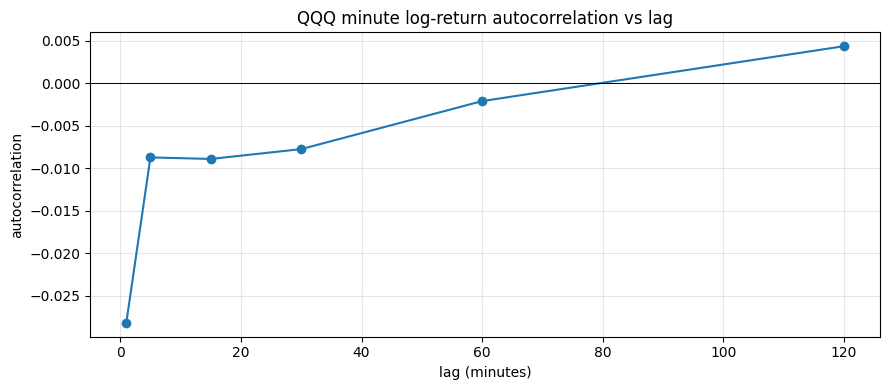

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(auto_all.keys()), list(auto_all.values()), marker="o")
ax.axhline(0, color="black", lw=0.7)
ax.set_xlabel("lag (minutes)")
ax.set_ylabel("autocorrelation")
ax.set_title("QQQ minute log-return autocorrelation vs lag")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


What this curve says:
- **Lag 1 is meaningfully negative** (−0.028). A positive minute bar tends to be followed by a negative minute bar. That's the signature of liquidity providers fading overshoots — exactly §2's mechanism.
- **The effect attenuates rapidly.** By lag 5 the magnitude has dropped 3×; by lag 60 it's essentially gone.
- **Lag 120 flips slightly positive** (+0.004). Two-hour-ahead minute returns weakly co-correlate — the early hint of trend continuation at longer intraday horizons. Not big enough to trade alone, but consistent with the §3 momentum mechanism kicking in once enough information has diffused.

So the autocorrelation curve says, on this 1-year QQQ window: **mean-reversion at the 1-minute horizon is real, momentum at the 2-hour horizon may be real, and there's a wide quiet zone between them.** Strategies in either family need to pick a horizon that lines up with the mechanism.

### Time-of-session conditioning

The all-RTH curve averages across very different parts of the session. Splitting lag-1 by time-of-session bucket:

| Bucket | Lag-1 ρ | Sessions |
|---|---|---|
| Opening 30 min (0–29)    | −0.0351 | 251 |
| Midday (60–299)          | −0.0346 | 251 |
| **Closing 30 min (360–389)** | **−0.0668** | 248 |

Computed below:

In [6]:
def bucket_autocorr(df, mask, lag):
    sub = df[mask]
    rs = []
    for _, s in sub.groupby("session_date")["log_ret"]:
        s = s.dropna()
        if len(s) < lag + 5:
            continue
        a, b = s.iloc[:-lag].values, s.iloc[lag:].values
        if a.std() == 0 or b.std() == 0:
            continue
        rs.append(np.corrcoef(a, b)[0, 1])
    return float(np.mean(rs)) if rs else float("nan"), len(rs)

buckets = {
    "opening 30 min (0-29)":  rth["minute_of_session"].between(0, 29),
    "midday (60-299)":         rth["minute_of_session"].between(60, 299),
    "closing 30 min (360-389)": rth["minute_of_session"].between(360, 389),
}
pd.DataFrame(
    [{"bucket": name, "rho_lag1": round(bucket_autocorr(rth, mask, 1)[0], 5),
      "n_sessions": bucket_autocorr(rth, mask, 1)[1]}
     for name, mask in buckets.items()]
)


,bucket,rho_lag1,n_sessions
0,opening 30 min (0-29),-0.03513,251
1,midday (60-299),-0.03464,251
2,closing 30 min (360-389),-0.06684,248


**The closing 30 minutes is where mean-reversion is cleanest** — roughly **2× the magnitude** of either opening or midday. This is the opposite of the textbook story (which says midday is cleanest because it's quietest), and it's an honest empirical finding worth dwelling on.

The likely interpretation: the closing window is not quiet; it's *mechanical*. End-of-day flows (closing-auction orders, MOC orders, index rebalance trades) create a high-volume environment where liquidity providers can fade overshoots aggressively because there's enough volume to actually do the fading. Midday is *quieter* — fewer overshoots, fewer participants, smaller mean-reversion in absolute magnitude. Opening is contaminated by overnight information absorption, which puts a momentum component on top of the mean-reversion and dilutes the signal.

This is good news for Ch8: the closing window gives a cleaner mean-reversion signal *and* is where capacity (executable size at a given price) is highest. Bad news: it's also where end-of-day mechanical flows are most active, which means the strategy must be careful not to fight the closing auction or MOC pressure on the last few minutes.

> **What if your data disagrees?** If you re-run §6 on a different window and the closing window is *not* the cleanest, that's information. Possible causes: a different vol regime, a window with more event days near the close, a window where index rebalances landed differently. The right move is the one we just made: report what you actually found, name a plausible mechanism, and check whether the result holds out-of-sample. The chapter is teaching the *method* of edge interrogation, not selling a fixed result.

## §7 — Why edges decay

Three drivers worth knowing:

1. **Crowding.** When too many people trade the same edge, the inefficiency that produced it gets arbitraged away. The classic case is equity stat-arb (pairs trading): pre-2010 Sharpes of 2-3 collapsed to 0.5-1 by the mid-2010s as the strategy went mainstream and the spreads it traded compressed. Crowding decay is *capacity-driven* — the more capital chasing the signal, the faster the decay.

2. **Regime change.** A mean-reversion strategy fit during a low-vol regime evaporates when vol regime-shifts upward. A momentum strategy fit during a clear macro trend dies when the trend reverses. Regime change is *state-driven* — the strategy isn't worse, the conditions changed. Ch15 (intraday vol & regime detection) is about catching these transitions.

3. **Parameter drift.** A strategy fit to 2018-2022 data may have been optimized to a regime that no longer exists post-2022 rate hikes. Even with the same family and mechanism, the *parameter values* that worked then no longer work now. Parameter drift is the most insidious decay: you didn't crowd the edge, the regime didn't shift dramatically, but the specific 5-minute lookback window or 1.5σ entry threshold you fit doesn't match current conditions. Ch10/Ch11 (backtesting bias and walk-forward) is largely about not falling for parameter-drift mirages.

> Ch9-11 (the backtesting trio) is largely about distinguishing *"edge that decayed"* from *"edge that was never there in the first place."* They are different failures with different remedies.

## §8 — So what?

Decision rules unlocked by this chapter:

- **Always answer "where does the edge come from, mechanically?" before building.** If you can't articulate a market mechanism in one sentence — liquidity-provision, slow info diffusion, range-compression-and-stop-run, scheduled-vol-window — you are curve-fitting, not edge-finding.
- **A strategy with hit rate 0.70 and payoff 0.30 has expectancy −0.09*R*; ignore hit rate without payoff context.** Hit rate alone is meaningless. Payoff alone is meaningless. Expectancy after costs is the only thing that decides profit.
- **Match horizon to mechanism.** Don't run a momentum strategy at 5-minute resolution on QQQ — the data says it's mean-reverting there. Don't run a mean-reversion strategy across an FOMC announcement — the mechanism reverses.
- **Edges decay; treat any historical edge as decaying unless proven otherwise.** Out-of-sample testing (Ch11) is how you tell whether what you saw in-sample is an edge or an artifact.

### What this chapter can't yet tell you

- How to build a runnable signal from a strategy idea — **Ch8.**
- How to know if a backtested edge is real vs spurious — **Ch9-11.**
- How to compute realistic costs on a backtest — **Ch12.**
- How to size a position given regime conditions — **Ch14, Ch15.**

## Key Terms

| Term | Definition |
| --- | --- |
| Breakout | Strategy family that trades range expansion after compression, often amplified by stop-runs. |
| Crowding | Capacity-based decay of an edge as more capital trades the same signal. |
| Edge | Positive expected value per trade, after realistic costs, in a defined regime. The only operational definition. |
| Event-driven | Strategy family that trades around scheduled news (FOMC, CPI, NFP, earnings). |
| Expectancy | Per-trade expected value: *p* · *w* − (1 − *p*) · *l*. |
| Fakeout | A breakout that reverses immediately, trapping breakout traders and triggering their stops. |
| Hit rate | Fraction of trades closed at a profit (before costs). Also called *win rate*. |
| Mean reversion | Strategy family that fades overshoots back toward fair value. Liquidity-providing in nature. |
| Momentum | Strategy family that trades the persistence of moves, driven by information diffusion + sliced execution. |
| Parameter drift | Edge decay where a strategy's fitted parameters become miscalibrated as the underlying regime changes. |
| Payoff ratio | avg_win / avg_loss. Measures how big winners are relative to losers in payoff units. |
| Profit factor | gross_winnings / gross_losses. >1 is profitable; >2 is strong; >3 over a long sample raises curve-fit suspicion. |
| Regime change | A market-state shift (e.g., vol regime, correlation regime) that switches edges on or off. Distinct from *regime* (Ch2): regime change is the *event*. |
| Time-horizon dual | The principle that mean-reversion at one timescale can be momentum at another. The same data is both. |
| Trend following | A subset of momentum framed by directional persistence rather than signal-based entry. |

## Up next

**Chapter 8 — Your first edge: intraday mean reversion on QQQ.** Build the strategy this chapter pointed at, end to end: idea → signal → naive backtest → first look at results. The closing-30-minute window from §6 is the primary harvesting window. Regression appears just-in-time as the signal-generation toolkit.

After that, three chapters of backtest discipline (Ch9-11), then execution realism (Ch12-13), sizing and regime detection (Ch14-15), more strategies (Ch16), futures mechanics (Ch17), and going live (Ch18).

## Exercises

1. **SPY lag-*k* autocorrelation comparison.**

   Load `../06-bridge-to-intraday/data/spy_1min.parquet`. Apply the same RTH filter and within-session autocorrelation computation as §6. Compute ρ at the same lag set {1, 5, 15, 30, 60, 120}. Plot QQQ and SPY autocorrelation curves on the same axes.

   Questions to answer in a paragraph:
   - Same shape? Same magnitude?
   - Where do they diverge, and why might that be?
   - SPY is broader-market and has more institutional flow than tech-heavy QQQ. Does that suggest more or less mean-reversion at sub-minute horizons?

2. **Expectancy arithmetic with cost subtraction.**

   Take the three §1 strategies: (hit, payoff) ∈ {(0.55, 0.9), (0.70, 0.3), (0.30, 3.0)}. Assume each strategy:
   - Places **30 trades per session**, 252 sessions per year
   - Has an average loss of 0.10% (so 1*R* = 0.10%; convert payoffs to percent and back for cost arithmetic)
   - Pays **0.5 bp = 0.005%** round-trip cost per trade

   Compute, for each strategy:
   - Expectancy at zero cost: per trade, per session, per year
   - Expectancy after cost: same three horizons
   - Cost as a fraction of zero-cost expectancy

   Questions:
   - Which strategy is most cost-sensitive (highest fraction lost to costs)? Why?
   - What round-trip cost would push the (0.55, 0.9) strategy to break-even?
   - At 30 trades/session, what session-level expectancy does each strategy produce after costs?

3. **FOMC vs non-FOMC autocorrelation.**

   Hardcode the FOMC date list from Ch6 §5 (or copy from `06-bridge-to-intraday/lesson.ipynb` cell `s5-fomc`). Build an `is_fomc` flag on `session_date`. Compute lag-1 autocorrelation conditioned on FOMC vs non-FOMC days.

   Hypothesis: *FOMC days have less short-horizon mean-reversion, because info dominates noise (the §3 mechanism for momentum/trend dominates over §2's mechanism for MR).*

   Test it on this window. Report the headline numbers and write a one-paragraph diagnostic answering:
   - Did the hypothesis hold?
   - **Important limitation:** the FOMC sub-sample is only 8 sessions in our 1-year window. Is the difference you measure large enough to be confident given that sample size? (Hint: think about how much sampling noise lives in an 8-session estimate of a small-magnitude correlation.)

4. **Identify the family.**

   Three prose strategy descriptions. For each, identify (a) the family, (b) the underlying mechanism in one sentence, and (c) at least one regime in which it would fail.

   *Strategy A:* "Buy QQQ in the 5 minutes before each FOMC announcement (14:00 ET); exit immediately at 14:01 ET regardless of direction. Hold a small fixed size."

   *Strategy B:* "When QQQ has had three consecutive 1-minute bars closing in the same direction during midday (12:00–14:00 ET), take a position in the *opposite* direction with a target of 0.1% and a stop of 0.15%. Hold for at most 30 minutes."

   *Strategy C:* "Track the high-of-day and low-of-day from 9:30–11:30. If by 11:30 the range is below 0.3% (compressed), take a position on the first 11:30+ bar that closes outside the range, in the direction of the breakout. Hold until end of day."

   Provide 1-2 sentences per strategy answering each of (a), (b), (c). At the end, name which strategy you'd be most cautious about deploying without a careful out-of-sample test, and why.